# 0. Preparación del Entorno

In [1]:
import pandas as pd
df = pd.read_csv("../../data\S07_PD_Diaz_DatasetSinOutliersfixed.csv")

<>:2: SyntaxWarning: invalid escape sequence '\S'
<>:2: SyntaxWarning: invalid escape sequence '\S'
C:\Users\diego\AppData\Local\Temp\ipykernel_26092\258019315.py:2: SyntaxWarning: invalid escape sequence '\S'
  df = pd.read_csv("../../data\S07_PD_Diaz_DatasetSinOutliersfixed.csv")


In [2]:
df.shape

(570976, 26)

Como los valores de df.shape son los mismos de la semana pasada, podemos continuar

In [3]:
df[["edad_cliente", "precio_unitario", "monto_compra", "unidades_vendidas"]].describe()

,edad_cliente,precio_unitario,monto_compra,unidades_vendidas
count,570976.000000,570976.000000,4.840860e+05,570976.000000
mean,46.394538,339302.369802,6.541967e+05,1.744895
std,14.940967,181364.338632,6.299378e+05,1.102294
min,18.000000,15100.000000,0.000000e+00,1.000000
25%,36.000000,203400.000000,2.214000e+05,1.000000
50%,46.000000,311700.000000,4.556000e+05,1.000000
75%,57.000000,445500.000000,8.514000e+05,2.000000
max,75.000000,899500.000000,4.450000e+06,5.000000


## Rangos antes de escalar
Se puede evidenciar que la columna monto_compra tiene el rango más alto, mientras que edad_cliente tiene el rango más bajo

# Arreglar los nulos de monto de compra 

In [4]:
print("Nulos en monto_compra ANTES de imputar:", df["monto_compra"].isna().sum())
print("Shape de df antes de imputar:", df.shape)

Nulos en monto_compra ANTES de imputar: 86890
Shape de df antes de imputar: (570976, 26)


## Imputación de nulos en `monto_compra` antes del escalamiento

Según el Plan de Saneamiento (S04), los nulos de `monto_compra` corresponden a un patrón que puede reconstruirse con datos de la misma fila: `precio_unitario * unidades_vendidas`. Esta imputación se hace **antes** del split y del escalado, porque no depende de ninguna estadística agregada del dataset (no hay riesgo de fuga de datos). Si escalamos con nulos presentes, el `StandardScaler`/`RobustScaler` conserva el `NaN` en vez de eliminarlo, dañando el conteo de filas y arrastrando el problema a etapas posteriores del pipeline.

In [5]:
df["monto_compra"] = df["monto_compra"].fillna(df["precio_unitario"] * df["unidades_vendidas"])

In [6]:
print("Nulos en monto_compra DESPUÉS de imputar:", df["monto_compra"].isna().sum())
print("Shape de df después de imputar:", df.shape)

Nulos en monto_compra DESPUÉS de imputar: 0
Shape de df después de imputar: (570976, 26)


In [17]:
print(df["monto_compra"].describe())

count    5.709760e+05
mean     6.020762e+05
std      5.929322e+05
min      0.000000e+00
25%      2.596000e+05
50%      3.639000e+05
75%      7.440000e+05
max      4.450000e+06
Name: monto_compra, dtype: float64


# 1. Preparación para un futuro modelo

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
df_entrenamiento, df_prueba = train_test_split(df, test_size=0.2, random_state=42)

In [9]:
suma_df = len(df_entrenamiento) + len(df_prueba)
print(suma_df)

570976


Se puede ver que la suma de los datos en entrenamiento y prueba son los mismos que en el dataset de la semana pasada.

## Por qué evito la fuga de datos
Para evitar la fuga de datos (data leakage), el escalador se ajusta únicamente utilizando df_entrenamiento. Esto es importante porque, si se calcula el escalador utilizando conjuntamente los datos de entrenamiento y de prueba, se estaría incorporando información del conjunto de prueba durante la etapa de entrenamiento.

Como consecuencia, la evaluación del modelo sobre los datos de prueba dejaría de ser completamente confiable, ya que estos datos habrían influido indirectamente en el proceso de transformación. Esto genera una contaminación del conjunto de prueba y puede producir métricas de rendimiento artificialmente optimistas.

Por esta razón, el escalador se ajusta (fit) exclusivamente con los datos de entrenamiento y posteriormente se aplica (transform) tanto al conjunto de entrenamiento como al conjunto de prueba, utilizando exactamente los mismos parámetros aprendidos durante el entrenamiento.

In [10]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

In [11]:
escalador_edad = StandardScaler()
escalador_monto = RobustScaler()
escalador_precio = StandardScaler()
escalador_unidades = StandardScaler()

escalador_edad.fit(df_entrenamiento[["edad_cliente"]])
escalador_monto.fit(df_entrenamiento[["monto_compra"]])
escalador_precio.fit(df_entrenamiento[["precio_unitario"]])
escalador_unidades.fit(df_entrenamiento[["unidades_vendidas"]])

StandardScaler()

In [12]:
escalador_edad.mean_

array([46.39607032])

In [13]:
df_entrenamiento["edad_cliente_escalada"] = escalador_edad.transform(df_entrenamiento[["edad_cliente"]])
df_prueba["edad_cliente_escalada"] = escalador_edad.transform(df_prueba[["edad_cliente"]])

df_entrenamiento["monto_compra_escalada"] = escalador_monto.transform(df_entrenamiento[["monto_compra"]])
df_prueba["monto_compra_escalada"] = escalador_monto.transform(df_prueba[["monto_compra"]])

df_entrenamiento["precio_unitario_escalada"] = escalador_precio.transform(df_entrenamiento[["precio_unitario"]])
df_prueba["precio_unitario_escalada"] = escalador_precio.transform(df_prueba[["precio_unitario"]])

df_entrenamiento["unidades_vendidas_escalada"] = escalador_unidades.transform(df_entrenamiento[["unidades_vendidas"]])
df_prueba["unidades_vendidas_escalada"] = escalador_unidades.transform(df_prueba[["unidades_vendidas"]])

In [14]:
df_entrenamiento.filter(like="_escalada").describe()
df_prueba.filter(like="_escalada").describe()

,edad_cliente_escalada,monto_compra_escalada,precio_unitario_escalada,unidades_vendidas_escalada
count,114196.000000,114196.000000,114196.000000,114196.000000
mean,-0.000513,0.495500,0.003195,0.000159
std,0.999973,1.222494,1.000731,0.999890
min,-1.900541,-0.750310,-1.779479,-0.675721
25%,-0.695806,-0.208798,-0.745496,-0.675721
50%,-0.026509,0.005679,-0.151576,-0.675721
75%,0.709718,0.794506,0.591788,0.231458
max,1.914453,8.329616,3.089891,2.952994


## Resultados del escalamiento

Se aplicó `StandardScaler` a `edad_cliente`, `precio_unitario` y `unidades_vendidas`, ya que estas variables no presentan asimetría extrema ni fueron afectadas por outliers severos tras la limpieza previa. Los resultados confirman un ajuste correcto: media ≈ 0 y desviación estándar ≈ 1 en las tres columnas.

Para `monto_compra` se usó `RobustScaler`, dado que esta variable conserva una distribución asimétrica (cola larga hacia valores altos, asociada a las ventas corporativas identificadas en S07). Por diseño, `RobustScaler` centra en la mediana (que queda en ≈0) y escala por el rango intercuartílico, por lo que no se espera media 0 ni desviación estándar 1 — la media de 0.50 y el máximo de 8.33 reflejan justamente esa cola larga que motivó la elección de este escalador sobre `StandardScaler`.

Todos los escaladores fueron ajustados (`.fit()`) únicamente con `df_entrenamiento`, evitando fuga de datos hacia el conjunto de prueba.

# 2. Transforma ambos conjuntos con el mismo escalador ya ajustado

## Transformación de train y test con los escaladores ya ajustados



In [26]:
# edad_cliente -> StandardScaler
df_entrenamiento["edad_cliente_escalada"] = escalador_edad.transform(df_entrenamiento[["edad_cliente"]])
df_prueba["edad_cliente_escalada"] = escalador_edad.transform(df_prueba[["edad_cliente"]])

# monto_compra -> RobustScaler
df_entrenamiento["monto_compra_escalada"] = escalador_monto.transform(df_entrenamiento[["monto_compra"]])
df_prueba["monto_compra_escalada"] = escalador_monto.transform(df_prueba[["monto_compra"]])

# precio_unitario -> StandardScaler
df_entrenamiento["precio_unitario_escalada"] = escalador_precio.transform(df_entrenamiento[["precio_unitario"]])
df_prueba["precio_unitario_escalada"] = escalador_precio.transform(df_prueba[["precio_unitario"]])

# unidades_vendidas -> StandardScaler
df_entrenamiento["unidades_vendidas_escalada"] = escalador_unidades.transform(df_entrenamiento[["unidades_vendidas"]])
df_prueba["unidades_vendidas_escalada"] = escalador_unidades.transform(df_prueba[["unidades_vendidas"]])

In [27]:
print("Describe df_entrenamiento (columnas escaladas):")
print(df_entrenamiento.filter(like="_escalada").describe())

print("\nDescribe df_prueba (columnas escaladas):")
print(df_prueba.filter(like="_escalada").describe())

Describe df_entrenamiento (columnas escaladas):
       edad_cliente_escalada  monto_compra_escalada  precio_unitario_escalada  \
count           4.567800e+05          456780.000000              4.567800e+05   
mean            1.327815e-16               0.492544              1.331548e-17   
std             1.000001e+00               1.225077              1.000001e+00   
min            -1.900541e+00              -0.750310             -1.787199e+00   
25%            -6.958059e-01              -0.215613             -7.493561e-01   
50%            -2.650887e-02               0.000000             -1.515762e-01   
75%             7.097179e-01               0.784387              5.851709e-01   
max             1.914453e+00               8.440107              3.086582e+00   

       unidades_vendidas_escalada  
count                4.567800e+05  
mean                 7.031072e-18  
std                  1.000001e+00  
min                 -6.757209e-01  
25%                 -6.757209e-01  
50%   

## Transformación de train y test con escaladores ya ajustados

Se aplicó `.transform()` (nunca `.fit()`) sobre `df_entrenamiento` y `df_prueba` por separado, reutilizando los cuatro escaladores ajustados exclusivamente con `df_entrenamiento` en el paso anterior. Esto evita fuga de datos: si el escalador se reajustara con `df_prueba`, este "vería" estadísticas del conjunto de prueba antes de la evaluación del modelo, invalidando la simulación de un escenario real de producción donde el modelo solo conoce los datos de entrenamiento al momento de ajustarse.

**Resultados:**

- En `df_entrenamiento`, las columnas escaladas con `StandardScaler` (`edad_cliente`, `precio_unitario`, `unidades_vendidas`) muestran media ≈ 0 y desviación estándar ≈ 1, como corresponde por definición matemática cuando el escalador se ajusta y transforma sobre el mismo conjunto.
- En `df_prueba`, las mismas columnas muestran media y desviación estándar cercanas pero no exactamente iguales a 0 y 1 (por ejemplo, edad: mean=-0.0005, std=0.9999). Esto confirma que el escalador **no se reajustó** con el test, solo se reutilizó la transformación aprendida en train.
- `monto_compra_escalada` (`RobustScaler`) mantiene una mediana cercana a 0 en ambos conjuntos (0.0 en train, 0.0057 en test) y rangos similares (min≈-0.75, max≈8.3-8.4), lo que indica coherencia entre train y test sin necesidad de que la media o el std sean 0/1, ya que este escalador no centra por esas métricas.
- Los rangos y percentiles son consistentes entre `df_entrenamiento` y `df_prueba` en las cuatro columnas, lo que sugiere que el split 80/20 fue representativo y no introdujo distribuciones muy distintas entre los dos conjuntos.

# 3. Compara un histograma antes y después del escalado

In [28]:
import matplotlib.pyplot as plt

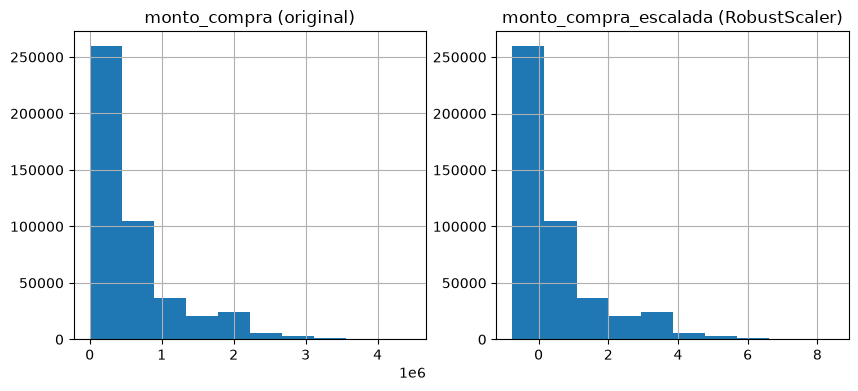

In [29]:
fig, ejes = plt.subplots(1, 2, figsize=(10, 4))
df_entrenamiento["monto_compra"].hist(ax=ejes[0])
df_entrenamiento["monto_compra_escalada"].hist(ax=ejes[1])

ejes[0].set_title("monto_compra (original)")
ejes[1].set_title("monto_compra_escalada (RobustScaler)")

plt.show()

## Comparación antes y después

La forma de la distribución de `monto_compra` se mantiene igual antes y después del escalado — la campana y su asimetría (cola hacia la derecha) no cambian. Lo único que se transforma es la escala del eje horizontal: de pesos colombianos (rango de miles a millones) a un rango centrado alrededor de 0, definido por la mediana y el IQR de `df_entrenamiento` (RobustScaler). Esto confirma que el escalado no altera la relación entre los datos, solo los reexpresa en una unidad distinta.

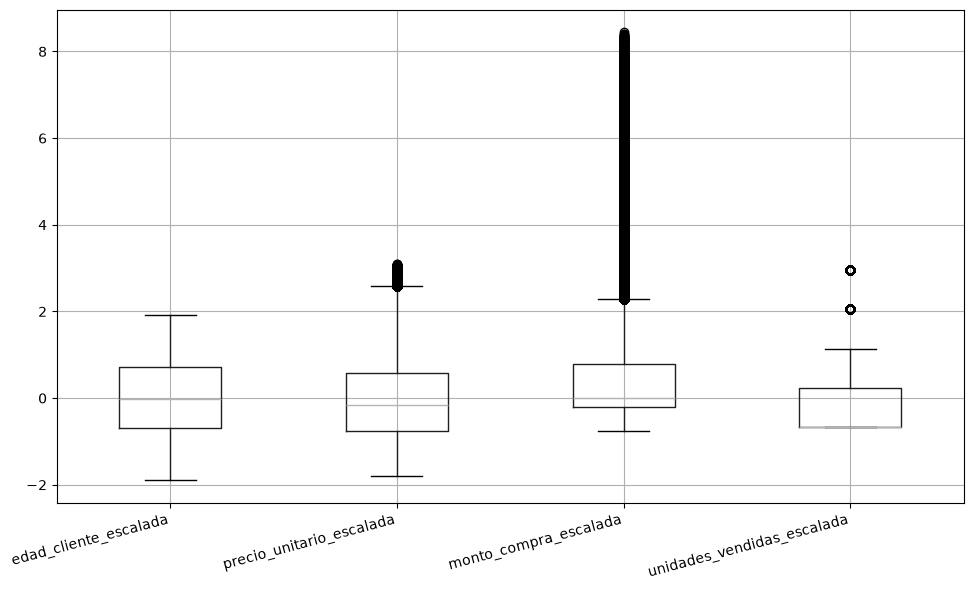

In [31]:
plt.figure(figsize=(10, 6))
df_entrenamiento[["edad_cliente_escalada", "precio_unitario_escalada", "monto_compra_escalada", "unidades_vendidas_escalada"]].boxplot()
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

## Boxplot comparativo

Ahora las cuatro variables se pueden observar en un mismo gráfico sin que una opaque a las demás. Antes del escalado, `monto_compra` (con valores en el orden de cientos de miles) habría aplastado visualmente a `edad_cliente` (rango de decenas), haciendo imposible comparar sus distribuciones en un solo boxplot. Al escalar todas las columnas a rangos comparables, se puede observar que `monto_compra_escalada` conserva más atípicos y mayor dispersión hacia valores altos que las demás — consistente con la asimetría que motivó el uso de `RobustScaler` para esta columna, frente al `StandardScaler` usado en las otras tres.

# 4. Justificacion de estandarizado

## Justificación de escalado por columna

- **`edad_cliente` → Z-score (`StandardScaler`)**: la distribución no presenta asimetría marcada ni atípicos severos tras la corrección de valores inválidos (rango final 18-75 años, sin los sentinels de -5 y 200 detectados originalmente). No hay una razón de negocio para conservar valores extremos como casos legítimos, por lo que centrar en media y escalar por desviación estándar es apropiado.

- **`precio_unitario` → Z-score (`StandardScaler`)**: se verificó con skewness (0.67, por debajo del umbral de asimetría marcada) y conteo de atípicos por IQR (1.02% del total) que la distribución es razonablemente simétrica una vez removido el sentinel de 999,000,000 identificado en la Semana 7. El bajo porcentaje de atípicos no justifica un escalador robusto, y estos casos residuales probablemente correspondan a las mismas ventas corporativas ya documentadas.

- **`monto_compra` → Escalado robusto (`RobustScaler`)**: esta columna conserva una cola larga hacia valores altos asociada a las ventas corporativas (`es_venta_corporativa`) documentadas y validadas como atípicos legítimos en la Semana 7. Un `StandardScaler` aquí distorsionaría la escala del resto de las transacciones normales, ya que la media y la desviación estándar se ven infladas por esos valores altos; centrar en mediana y escalar por IQR evita ese efecto sin necesidad de eliminar o alterar los atípicos legítimos.

- **`unidades_vendidas` → Z-score (`StandardScaler`)**: tras la corrección de valores inválidos (min=-3 y max=9999 en el dataset original), la columna quedó concentrada mayoritariamente en valores bajos (1-5 unidades por transacción), sin atípicos que ameriten un tratamiento robusto. Se usó Z-score siguiendo el mismo criterio que `edad_cliente` y `precio_unitario`.

# 5. data set final 

In [32]:
df_final = pd.concat([df_entrenamiento, df_prueba])

In [33]:
print("Shape df_final:", df_final.shape)
print("Shape df original:", df.shape)
print("\nColumnas en df_final:")
print(df_final.columns.tolist())

Shape df_final: (570976, 30)
Shape df original: (570976, 26)

Columnas en df_final:
['id_pedido', 'id_cliente', 'fecha_pedido', 'canal_compra', 'metodo_pago', 'ciudad_tienda', 'codigo_postal', 'categoria_producto', 'producto', 'precio_unitario', 'unidades_vendidas', 'monto_compra', 'edad_cliente', 'correo_cliente', 'nivel_satisfaccion', 'nivel_lealtad', 'comentario_cliente', 'peso_pedido_kg', 'fecha_actualizacion_stock', 'fuga_cliente', 'correo_cliente_faltante', 'comentario_cliente_faltante', 'es_venta_corporativa', 'edad_cliente_era_nulo', 'precio_unitario_era_nulo', 'unidades_vendidas_era_nulo', 'edad_cliente_escalada', 'monto_compra_escalada', 'precio_unitario_escalada', 'unidades_vendidas_escalada']


In [34]:
df_final.to_csv("S08_PD_Torres_DatasetEscalado.csv", index=False)

In [35]:
df_verificacion = pd.read_csv("S08_PD_Torres_DatasetEscalado.csv")
print("Shape:", df_verificacion.shape)
print("\nColumnas:")
print(df_verificacion.columns.tolist())

Shape: (570976, 30)

Columnas:
['id_pedido', 'id_cliente', 'fecha_pedido', 'canal_compra', 'metodo_pago', 'ciudad_tienda', 'codigo_postal', 'categoria_producto', 'producto', 'precio_unitario', 'unidades_vendidas', 'monto_compra', 'edad_cliente', 'correo_cliente', 'nivel_satisfaccion', 'nivel_lealtad', 'comentario_cliente', 'peso_pedido_kg', 'fecha_actualizacion_stock', 'fuga_cliente', 'correo_cliente_faltante', 'comentario_cliente_faltante', 'es_venta_corporativa', 'edad_cliente_era_nulo', 'precio_unitario_era_nulo', 'unidades_vendidas_era_nulo', 'edad_cliente_escalada', 'monto_compra_escalada', 'precio_unitario_escalada', 'unidades_vendidas_escalada']
